In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms

from transformers import ViTForImageClassification, ViTFeatureExtractor
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

c:\Users\ASUS\OneDrive\Desktop\Brain_tumor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
GPU: N/A


In [3]:
CONFIG = {
    "data_dir": "../data",
    "model_save_path": "../model/vit_brain_tumor.pth",
    "model_name": "google/vit-base-patch16-224",
    "num_classes": 4,
    "class_names": ["glioma", "meningioma", "notumor", "pituitary"],
    "image_size": 224,
    "batch_size": 16,
    "num_epochs": 10,
    "learning_rate": 2e-5,       # Low LR for fine-tuning pretrained backbone
    "weight_decay": 1e-2,
    "unfreeze_after_epoch": 3,   # Freeze backbone for first 3 epochs, then unfreeze
    "num_workers": 0,
}

os.makedirs("../model", exist_ok=True)
print("Config loaded.")

Config loaded.


=== Training set ===
     class  count                                 sample_path
    glioma   1400         ..\data\Training\glioma\Tr-gl_1.jpg
meningioma   1400 ..\data\Training\meningioma\Tr-aug-me_1.jpg
   notumor   1400        ..\data\Training\notumor\Tr-no_1.jpg
 pituitary   1400      ..\data\Training\pituitary\Tr-pi_1.jpg

Total training images: 5600

=== Testing set ===
     class  count                                sample_path
    glioma    400         ..\data\Testing\glioma\Te-gl_1.jpg
meningioma    400 ..\data\Testing\meningioma\Te-aug-me_1.jpg
   notumor    400        ..\data\Testing\notumor\Te-no_1.jpg
 pituitary    400      ..\data\Testing\pituitary\Te-pi_1.jpg
Total testing images: 1600


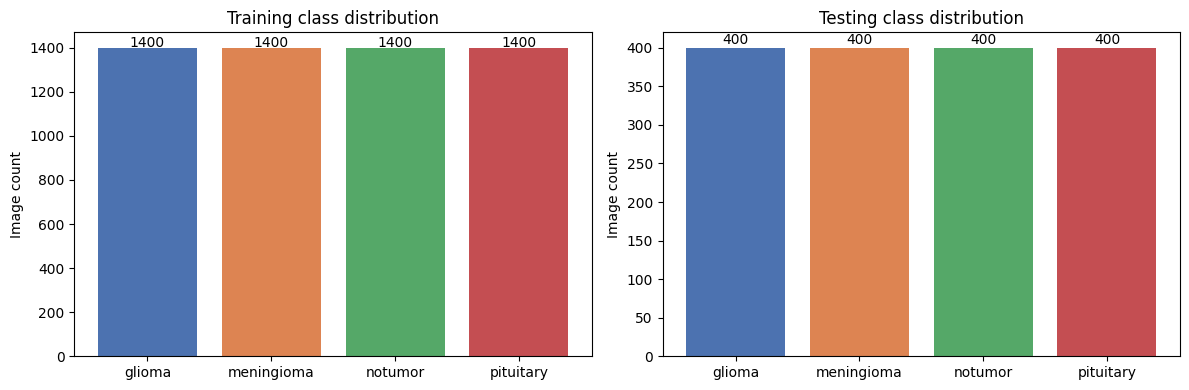

In [4]:
def explore_dataset(data_dir: str, split: str = "Training") -> pd.DataFrame:
    split_path = Path(data_dir) / split
    records = []
    for class_dir in sorted(split_path.iterdir()):
        if class_dir.is_dir():
            images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.png"))
            records.append({
                "class": class_dir.name,
                "count": len(images),
                "sample_path": str(images[0]) if images else None
            })
    return pd.DataFrame(records)

train_df = explore_dataset(CONFIG["data_dir"], "Training")
test_df  = explore_dataset(CONFIG["data_dir"], "Testing")

print("=== Training set ===")
print(train_df.to_string(index=False))
print(f"\nTotal training images: {train_df['count'].sum()}")
print("\n=== Testing set ===")
print(test_df.to_string(index=False))
print(f"Total testing images: {test_df['count'].sum()}")

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in zip(axes, [train_df, test_df], ["Training", "Testing"]):
    bars = ax.bar(df["class"], df["count"], color=["#4C72B0","#DD8452","#55A868","#C44E52"])
    ax.set_title(f"{title} class distribution")
    ax.set_ylabel("Image count")
    for bar, count in zip(bars, df["count"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(count), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("../model/class_distribution.png", dpi=150)
plt.show()

In [5]:
class BrainTumorDataset(Dataset):
    def __init__(self, data_dir: str, split: str, transform=None):
        self.data_dir = Path(data_dir) / split
        self.transform = transform
        self.class_names = sorted([
            d.name for d in self.data_dir.iterdir() if d.is_dir()
        ])
        self.class_to_idx = {c: i for i, c in enumerate(self.class_names)}
        self.samples = self._load_samples()

    def _load_samples(self) -> list[tuple[str, int]]:
        samples = []
        for class_name in self.class_names:
            class_dir = self.data_dir / class_name
            for img_path in class_dir.glob("*"):
                if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                    samples.append((str(img_path), self.class_to_idx[class_name]))
        return samples

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # ViT standard
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Datasets
train_dataset = BrainTumorDataset(CONFIG["data_dir"], "Training", train_transform)
test_dataset  = BrainTumorDataset(CONFIG["data_dir"], "Testing",  val_transform)

print(f"Train samples : {len(train_dataset)}")
print(f"Test  samples : {len(test_dataset)}")
print(f"Classes       : {train_dataset.class_names}")
print(f"Class→idx     : {train_dataset.class_to_idx}")

Train samples : 5600
Test  samples : 1600
Classes       : ['glioma', 'meningioma', 'notumor', 'pituitary']
Class→idx     : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [7]:
def make_weighted_sampler(dataset: BrainTumorDataset) -> WeightedRandomSampler:
    labels = [label for _, label in dataset.samples]
    class_counts = Counter(labels)
    weights = [1.0 / class_counts[label] for label in labels]
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_sampler = make_weighted_sampler(train_dataset)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    sampler=train_sampler,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Train batches: 350 | Test batches: 100


In [8]:
def build_model(num_classes: int, model_name: str) -> ViTForImageClassification:
    model = ViTForImageClassification.from_pretrained(
        model_name,
        num_labels=num_classes,
        ignore_mismatched_sizes=True,   # replaces the pretrained head
    )
    # Freeze backbone initially — only train the classifier head
    for name, param in model.named_parameters():
        if "classifier" not in name:
            param.requires_grad = False

    total  = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params    : {total:,}")
    print(f"Trainable params: {trainable:,} (head only, backbone frozen)")
    return model

model = build_model(CONFIG["num_classes"], CONFIG["model_name"])
model = model.to(DEVICE)

c:\Users\ASUS\OneDrive\Desktop\Brain_tumor\venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([4]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total params    : 85,801,732
Trainable params: 3,076 (head only, backbone frozen)


In [9]:
def unfreeze_backbone(model: ViTForImageClassification) -> None:
    for param in model.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Backbone unfrozen — trainable params: {trainable:,}")


def train_one_epoch(
    model, loader, optimizer, criterion, scaler, device
) -> tuple[float, float]:
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(pixel_values=images).logits
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(
    model, loader, criterion, device
) -> tuple[float, float]:
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="Val  ", leave=False):
        images, labels = images.to(device), labels.to(device)
        with autocast():
            outputs = model(pixel_values=images).logits
            loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

In [10]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG["num_epochs"]
)
scaler = GradScaler()

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(1, CONFIG["num_epochs"] + 1):

    # Unfreeze backbone after warm-up epochs
    if epoch == CONFIG["unfreeze_after_epoch"] + 1:
        unfreeze_backbone(model)
        # Re-init optimizer to include all params
        optimizer = optim.AdamW(
            model.parameters(),
            lr=CONFIG["learning_rate"] / 5,   # Lower LR for backbone
            weight_decay=CONFIG["weight_decay"],
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=CONFIG["num_epochs"] - epoch
        )

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, DEVICE
    )
    val_loss, val_acc = evaluate(model, test_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d}/{CONFIG['num_epochs']} | "
        f"Train loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}  acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CONFIG["model_save_path"])
        print(f"  ✓ Saved best model (val_acc={best_val_acc:.4f})")

print(f"\nTraining complete. Best val accuracy: {best_val_acc:.4f}")

c:\Users\ASUS\OneDrive\Desktop\Brain_tumor\venv\Lib\site-packages\torch\cuda\amp\grad_scaler.py:126: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
Train:   0%|          | 0/350 [00:00<?, ?it/s]

c:\Users\ASUS\OneDrive\Desktop\Brain_tumor\venv\Lib\site-packages\torch\amp\autocast_mode.py:250: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Epoch 01/10 | Train loss: 1.2548  acc: 0.4841 | Val loss: 1.1851  acc: 0.5331
  ✓ Saved best model (val_acc=0.5331)


Epoch 02/10 | Train loss: 1.0581  acc: 0.6546 | Val loss: 1.0852  acc: 0.5837
  ✓ Saved best model (val_acc=0.5837)


Epoch 03/10 | Train loss: 0.9730  acc: 0.6977 | Val loss: 1.0419  acc: 0.5944
  ✓ Saved best model (val_acc=0.5944)
Backbone unfrozen — trainable params: 85,801,732


...

Epoch 06/10 | Train loss: 0.4451  acc: 0.9584 | Val loss: 0.5464  acc: 0.9144
  ✓ Saved best model (val_acc=0.9144)


Epoch 07/10 | Train loss: 0.4244  acc: 0.9725 | Val loss: 0.5215  acc: 0.9319
  ✓ Saved best model (val_acc=0.9319)


Epoch 08/10 | Train loss: 0.4141  acc: 0.9757 | Val loss: 0.5239  acc: 0.9313


Epoch 09/10 | Train loss: 0.4125  acc: 0.9786 | Val loss: 0.5199  acc: 0.9331
  ✓ Saved best model (val_acc=0.9331)


Epoch 10/10 | Train loss: 0.4024  acc: 0.9857 | Val loss: 0.5199  acc: 0.9331

Training complete. Best val accuracy: 0.9331
